In [33]:
from dateutil import parser
import matplotlib.pyplot as plt
import rasters as rt
from GEOS5FP import GEOS5FPConnection
from JET3 import process_JET_table, load_ECOv002_calval_JET_inputs

In [2]:
RH_filename = "~/Library/CloudStorage/OneDrive-JPL/data/ECOv003_L3T_ETAUX_41310_012_11SPS_20251018T192142_01_RH.tif"

In [15]:
GEOS5FP = GEOS5FPConnection()

In [12]:
timestamp = RH_filename.split("_")[-3]
time_UTC = parser.parse(timestamp)
time_UTC

datetime.datetime(2025, 10, 18, 19, 21, 42)

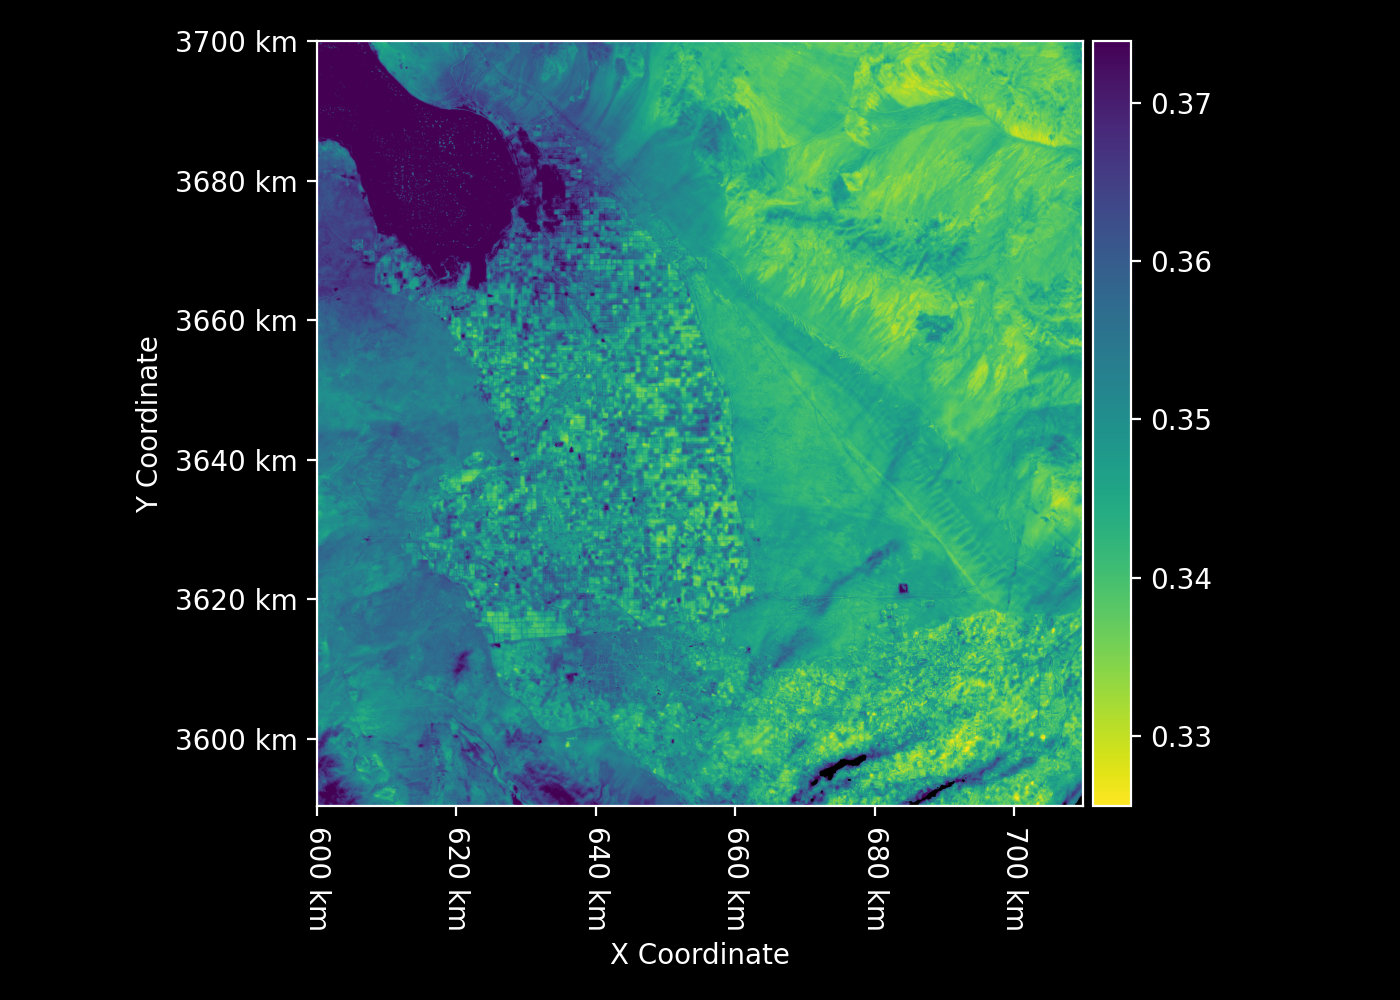

In [18]:
RH_downscaled = rt.Raster.open(RH_filename)
RH_downscaled.cmap = "viridis_r"
RH_downscaled

In [5]:
geometry = RH_downscaled.geometry
geometry

{
  "dimensions": {
    "rows": 1568,
    "cols": 1568
  },
  "bbox": {
    "xmin": 600000.0,
    "ymin": 3590260.0,
    "xmax": 709760.0,
    "ymax": 3700020.0
  },
  "crs": "EPSG:32611",
  "resolution": {
    "cell_width": 70.0,
    "cell_height": -70.0
  }
}

[2026-08-25 14:30:16 INFO] retrieving Q from GEOS-5 FP tavg1_2d_slv_Nx QV2M for 2025-10-18 19:21 UTC
[2026-08-25 14:30:16 INFO] searching GEOS-5 FP tavg1_2d_slv_Nx at 2025-10-18 19:21:42 UTC
[2026-08-25 14:30:16 INFO] listing available tavg1_2d_slv_Nx files for 2025-10-18...
[2026-08-25 14:30:16 INFO] found 26 tavg1_2d_slv_Nx files, finding bracketing times...
[2026-08-25 14:30:16 INFO] before time: 2025-10-18 18:30 UTC
[2026-08-25 14:30:16 INFO] after time: 2025-10-18 19:30 UTC
[2026-08-25 14:30:16 INFO] downloading/loading before granule...
[2026-08-25 14:30:16 INFO] checking existing file: ~/data/GEOS5FP/2025.10.18/GEOS.fp.asm.tavg1_2d_slv_Nx.20251018_1830.V01.nc4
[2026-08-25 14:30:17 INFO] existing file is valid: ~/data/GEOS5FP/2025.10.18/GEOS.fp.asm.tavg1_2d_slv_Nx.20251018_1830.V01.nc4 (71.09 MB)
[2026-08-25 14:30:17 INFO] downloading/loading after granule...
[2026-08-25 14:30:17 INFO] checking existing file: ~/data/GEOS5FP/2025.10.18/GEOS.fp.asm.tavg1_2d_slv_Nx.20251018_1930.V01

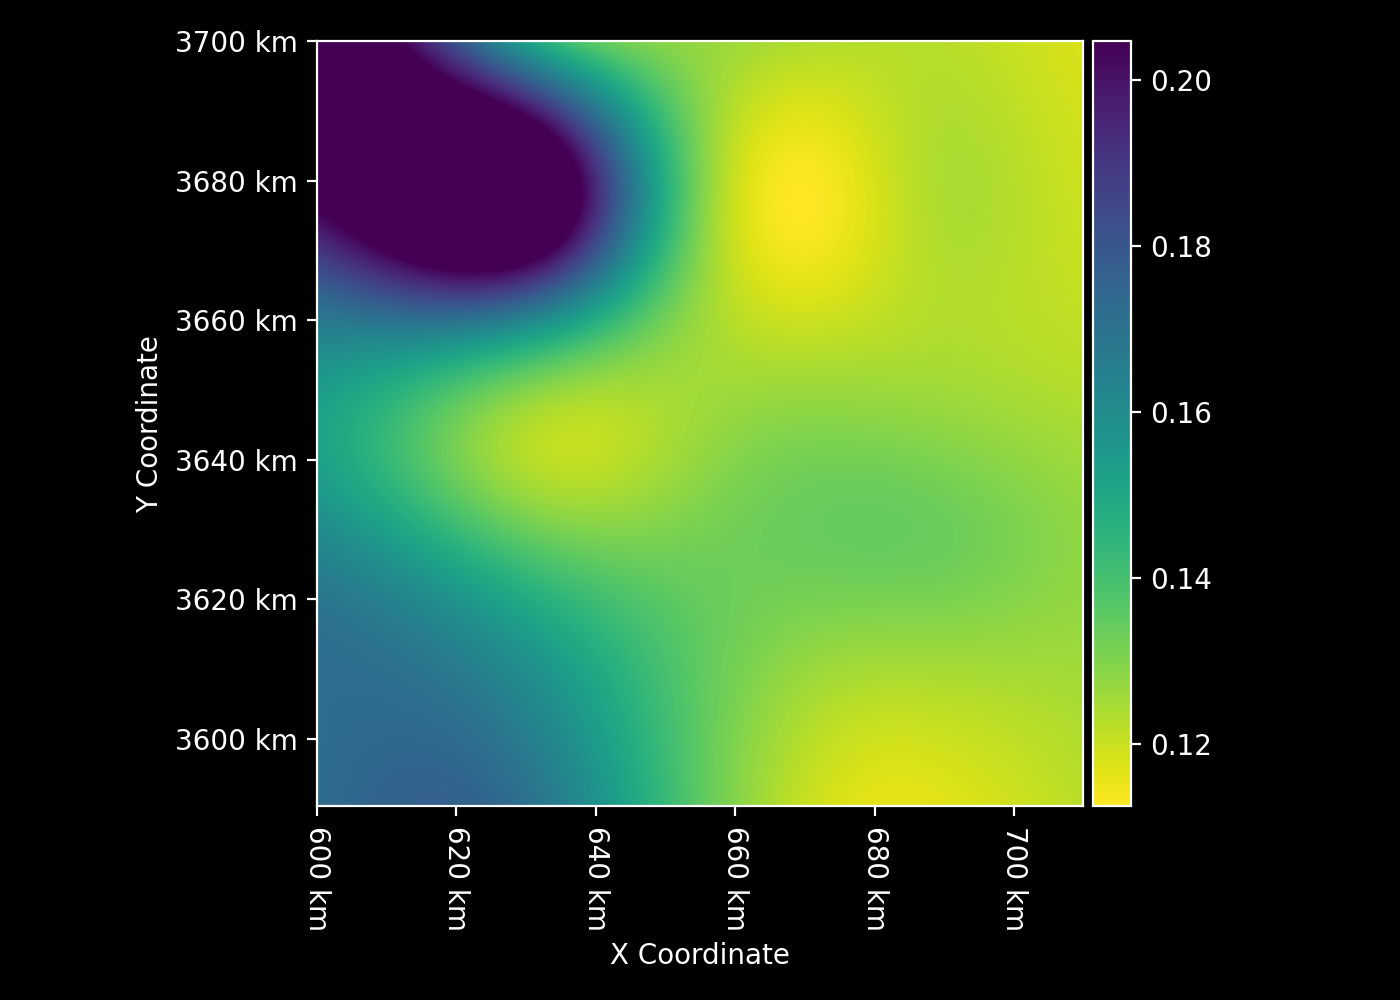

In [19]:
RH_coarse = GEOS5FP.RH(time_UTC=time_UTC, geometry=geometry)
RH_coarse.cmap = "viridis_r"
RH_coarse

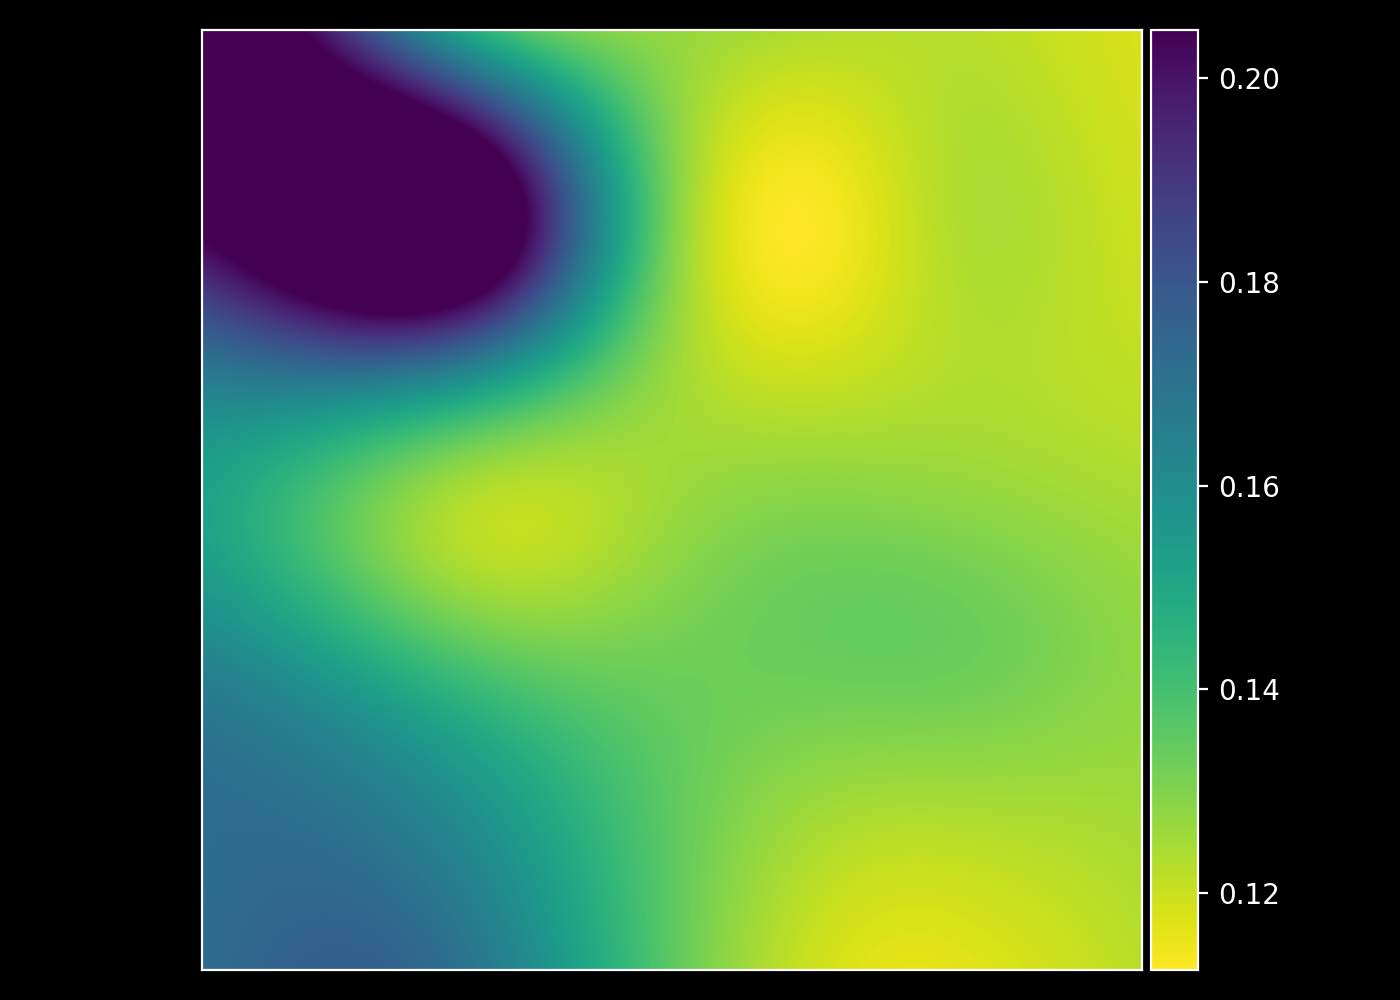

In [22]:
RH_coarse.imshow(hide_ticks=True)

In [27]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
RH_downscaled.imshow(ax=axes[0], hide_ticks=True)
axes[0].set_title("Downscaled RH")
RH_coarse.imshow(ax=axes[1], hide_ticks=True)
axes[1].set_title("Coarse RH from GEOS5FP")
plt.show()

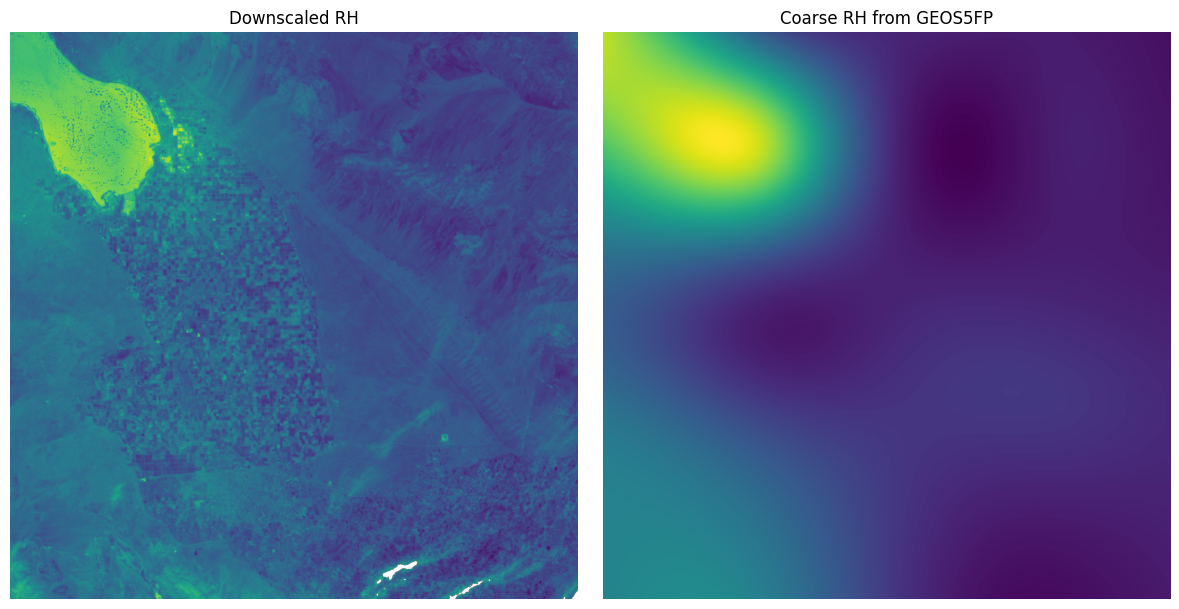

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(RH_downscaled.squeeze())
axes[0].set_title("Downscaled RH")
axes[0].axis('off')

axes[1].imshow(RH_coarse.squeeze())
axes[1].set_title("Coarse RH from GEOS5FP")
axes[1].axis('off')

plt.tight_layout()
plt.show()

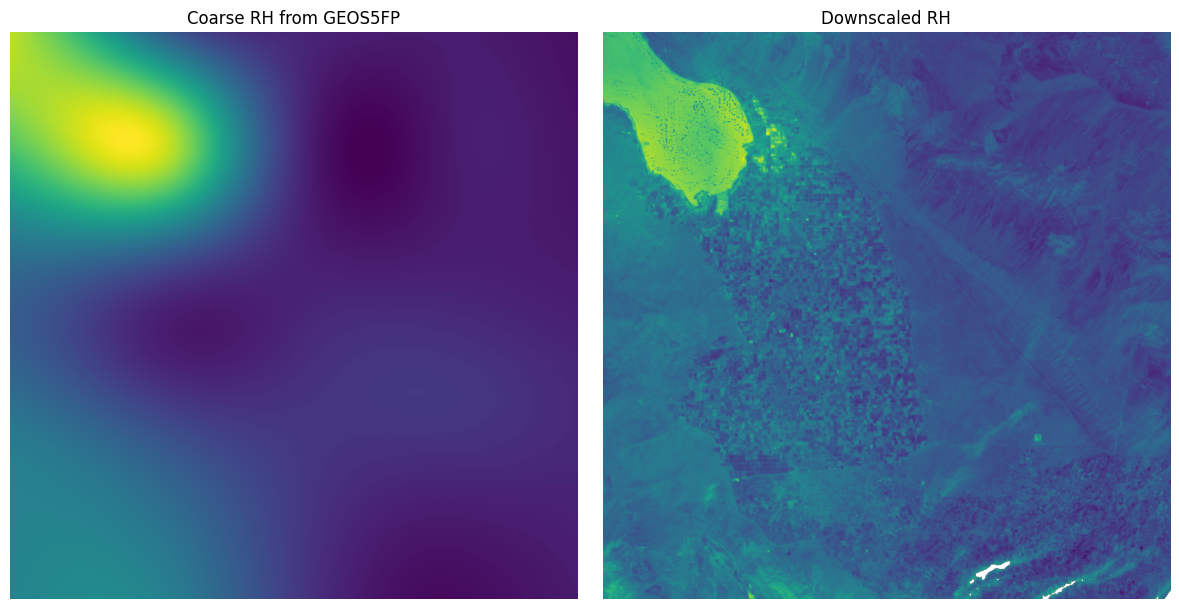

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Coarse RH on the left
axes[0].imshow(RH_coarse.squeeze())
axes[0].set_title("Coarse RH from GEOS5FP")
axes[0].axis('off')

# Downscaled RH on the right
axes[1].imshow(RH_downscaled.squeeze())
axes[1].set_title("Downscaled RH")
axes[1].axis('off')

plt.tight_layout()
plt.show()

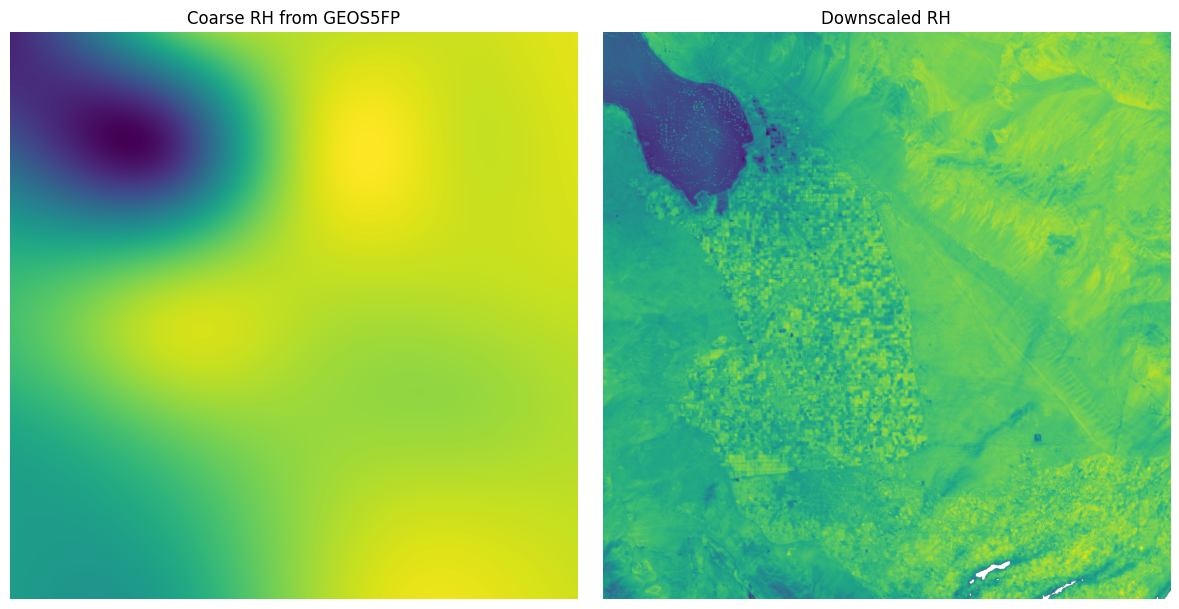

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Coarse RH on the left
axes[0].imshow(RH_coarse.squeeze(), cmap="viridis_r")
axes[0].set_title("Coarse RH from GEOS5FP")
axes[0].axis('off')

# Downscaled RH on the right
axes[1].imshow(RH_downscaled.squeeze(), cmap="viridis_r")
axes[1].set_title("Downscaled RH")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [34]:
input_df = load_ECOv002_calval_JET_inputs()
processed = process_JET_table(input_df)
processed

[2026-08-25 14:50:33 INFO] starting JET table processing
[2026-08-25 14:50:33 INFO] started extracting geometry from JET input table
[2026-08-25 14:50:33 INFO] completed extracting geometry from JET input table (0.011 seconds)
[2026-08-25 14:50:33 INFO] started extracting time from JET input table
[2026-08-25 14:50:33 INFO] completed extracting time from JET input table (0.002 seconds)
[2026-08-25 14:50:33 INFO] running Forest Light Environmental Simulator
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[2026-08-25 14:50:33 INFO] completed processing FLiES-ANN in 0.25 seconds
[2026-08-25 14:50:33 INFO] variable PAR_albedo min: 0.003 mean: 0.052 max: 0.681 nan: 0.00% (nan)
[2026-08-25 14:50:33 INFO] variable NIR_albedo min: 0.028 mean: 0.164 max: 0.582 nan: 0.00% (nan)
[2026-08-25 14:50:33 INFO] variable PAR_direct_Wm2 min: 4.617 mean: 266.198 max: 473.257 nan: 0.38% (nan)
[2026-08-25 14:50:33 INFO] variable SWin_FLiES_ANN min: 104.662 mean: 715.359 max: 1153.185 nan: 0.38% (nan)
[2026-08-25 14:

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


[2026-08-25 14:50:34 INFO] completed daylight ET upscaling (PMJPL)
[2026-08-25 14:50:34 INFO] completed processing PM-JPL in 0.16 seconds
[2026-08-25 14:50:34 INFO] variable LE_PMJPL_Wm2 min: 0.000 mean: 133.268 max: 559.998 nan: 0.56% (nan)
[2026-08-25 14:50:34 INFO] variable ET_daylight_PMJPL_kg min: 0.000 mean: 1.856 max: 7.137 nan: 0.56% (nan)
[2026-08-25 14:50:34 INFO] variable G_PMJPL_Wm2 min: 0.000 mean: 65.311 max: 222.087 nan: 0.56% (nan)
[2026-08-25 14:50:34 INFO] variable ET_daylight_kg min: 0.000 mean: 2.363 max: 7.164 nan: 0.00% (nan)
[2026-08-25 14:50:34 INFO] JET table processing complete (0.799 seconds)


/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')


,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,G_PMJPL_Wm2,G_Wm2,LE_instantaneous_Wm2,LE_Wm2,H_Wm2,ET_daylight_kg,ET_uncertainty,GPP_inst_g_m2_s,ET_canopy_inst_kg_m2_s,WUE
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,60.425858,60.425858,351.448461,351.448461,54.761772,4.144935,0.773774,0.000212,0.000109,1.943556
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,99.328964,99.328964,326.039533,326.039533,360.706912,4.279363,1.239315,0.000269,0.000111,2.421845
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,94.519459,94.519459,335.227018,335.227018,306.110166,4.353823,0.920482,0.000251,0.000044,5.670131
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,78.277108,78.277108,332.815927,332.815927,345.610073,4.433066,0.372526,0.000303,0.000049,6.158837
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,70.628272,70.628272,290.934683,290.934683,260.113128,4.244395,0.368856,0.000283,0.000058,4.846558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,5.985290,5.985290,35.172963,35.172963,196.977862,0.423263,0.427738,0.000006,0.000008,0.723558
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,23.006292,23.006292,37.569782,37.569782,187.016966,0.815033,1.326901,0.000015,0.000012,1.260016
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,43.185134,43.185134,27.267394,27.267394,258.399557,0.585193,0.710205,0.000041,0.000031,1.332510
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,28.164664,28.164664,58.151032,58.151032,265.153028,1.076440,0.606770,0.000024,0.000023,1.048858


In [42]:
towers = sorted(set(processed.ID))
towers

['CA-Cbo',
 'PR-xGU',
 'US-ARM',
 'US-CMW',
 'US-CS5',
 'US-DFC',
 'US-HB2',
 'US-HB3',
 'US-HBK',
 'US-Jo2',
 'US-KM4',
 'US-MMS',
 'US-Me2',
 'US-Me6',
 'US-Mi1',
 'US-Mi3',
 'US-NC2',
 'US-NC3',
 'US-NC4',
 'US-NR3',
 'US-NR4',
 'US-ONA',
 'US-PAS',
 'US-PFe',
 'US-PFn',
 'US-PFr',
 'US-Rls',
 'US-Rms',
 'US-Ro4',
 'US-Rwf',
 'US-Rws',
 'US-SP1',
 'US-SRG',
 'US-SRM',
 'US-Syv',
 'US-UC1',
 'US-UC2',
 'US-UMd',
 'US-UiB',
 'US-WCr',
 'US-Whs',
 'US-Wkg',
 'US-xAB',
 'US-xAE',
 'US-xBL',
 'US-xBR',
 'US-xCL',
 'US-xDL',
 'US-xJE',
 'US-xJR',
 'US-xKA',
 'US-xML',
 'US-xRM',
 'US-xRN',
 'US-xSB',
 'US-xSL',
 'US-xST',
 'US-xTE',
 'US-xTR',
 'US-xUK',
 'US-xUN',
 'US-xWR',
 'US-xYE']

In [43]:
for tower in towers:
    print(tower, len(processed[processed.ID == tower]))

CA-Cbo 2
PR-xGU 3
US-ARM 26
US-CMW 55
US-CS5 2
US-DFC 8
US-HB2 1
US-HB3 12
US-HBK 7
US-Jo2 29
US-KM4 17
US-MMS 46
US-Me2 13
US-Me6 53
US-Mi1 5
US-Mi3 5
US-NC2 12
US-NC3 1
US-NC4 1
US-NR3 2
US-NR4 2
US-ONA 10
US-PAS 3
US-PFe 1
US-PFn 1
US-PFr 2
US-Rls 41
US-Rms 23
US-Ro4 13
US-Rwf 36
US-Rws 39
US-SP1 6
US-SRG 68
US-SRM 65
US-Syv 9
US-UC1 9
US-UC2 6
US-UMd 15
US-UiB 12
US-WCr 16
US-Whs 76
US-Wkg 68
US-xAB 17
US-xAE 21
US-xBL 8
US-xBR 10
US-xCL 18
US-xDL 2
US-xJE 12
US-xJR 28
US-xKA 20
US-xML 8
US-xRM 4
US-xRN 4
US-xSB 6
US-xSL 4
US-xST 6
US-xTE 17
US-xTR 12
US-xUK 8
US-xUN 12
US-xWR 20
US-xYE 7


In [45]:
tower_df = processed[processed.ID == "US-Wkg"]
tower_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,G_PMJPL_Wm2,G_Wm2,LE_instantaneous_Wm2,LE_Wm2,H_Wm2,ET_daylight_kg,ET_uncertainty,GPP_inst_g_m2_s,ET_canopy_inst_kg_m2_s,WUE
336,336,US-Wkg,GRA,Bsk,43.319706,198.179960,24.796133,54.517956,37.778450,69.048460,...,9.853011,9.853011,47.456698,47.456698,122.028869,1.040745,0.832206,2.464756e-06,0.000003,0.759550
337,337,US-Wkg,GRA,Bsk,117.093420,0.000000,58.096360,37.871230,52.564499,42.782482,...,32.979050,32.979050,45.911150,45.911150,160.741672,1.320817,1.421846,2.894782e-05,0.000016,1.756810
338,338,US-Wkg,GRA,Bsk,251.765470,0.000000,162.898380,83.628540,106.272400,93.382600,...,115.758696,115.758696,65.690387,65.690387,360.090634,1.023874,1.167999,1.976092e-06,0.000037,0.053219
339,339,US-Wkg,GRA,Bsk,227.103290,148.145100,326.802150,349.868100,250.988403,92.927450,...,110.844497,110.844497,218.259785,218.259785,352.861756,2.291940,1.645011,7.272024e-05,0.000068,1.076452
340,340,US-Wkg,GRA,Bsk,187.399700,263.706180,290.427900,311.339450,200.958435,50.483307,...,94.824604,94.824604,177.777646,177.777646,361.705385,1.884282,1.521382,8.682610e-05,0.000062,1.398838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,399,US-Wkg,GRA,Bsk,146.093900,6.126423,68.987410,30.606745,74.727646,52.761925,...,108.484437,108.484437,29.260172,29.260172,327.737894,0.545698,1.241018,3.527195e-07,0.000016,0.021940
400,400,US-Wkg,GRA,Bsk,244.021060,62.378765,106.305695,46.880370,70.660553,76.145640,...,158.015579,158.015579,39.114948,39.114948,468.946226,0.573805,1.168128,2.807149e-07,0.000024,0.011937
401,401,US-Wkg,GRA,Bsk,283.164120,46.612957,113.939384,51.941593,65.507500,95.686410,...,197.251389,197.251389,44.425513,44.425513,488.930283,0.649227,1.299339,3.263429e-08,0.000027,0.001212
402,402,US-Wkg,GRA,Bsk,289.893550,55.310780,114.550800,52.089443,NaN,96.065790,...,209.150191,209.150191,45.068343,45.068343,492.995391,0.653257,1.195728,1.760828e-08,0.000028,0.000640


In [62]:
tower_df[tower_df.time_UTC.apply(lambda x: str(x)[:7] == "2022-05")]

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,G_Wm2,LE_instantaneous_Wm2,LE_Wm2,H_Wm2,ET_daylight_kg,ET_uncertainty,GPP_inst_g_m2_s,ET_canopy_inst_kg_m2_s,WUE,month
399,399,US-Wkg,GRA,Bsk,146.09390,6.126423,68.987410,30.606745,74.727646,52.761925,...,108.484437,29.260172,29.260172,327.737894,0.545698,1.241018,3.527195e-07,0.000016,0.021940,2022-05
400,400,US-Wkg,GRA,Bsk,244.02106,62.378765,106.305695,46.880370,70.660553,76.145640,...,158.015579,39.114948,39.114948,468.946226,0.573805,1.168128,2.807149e-07,0.000024,0.011937,2022-05


In [61]:
tower_df[(tower_df.time_UTC > "2022-05") & (tower_df.time_UTC < "2022-06")]

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,G_Wm2,LE_instantaneous_Wm2,LE_Wm2,H_Wm2,ET_daylight_kg,ET_uncertainty,GPP_inst_g_m2_s,ET_canopy_inst_kg_m2_s,WUE,month
399,399,US-Wkg,GRA,Bsk,146.09390,6.126423,68.987410,30.606745,74.727646,52.761925,...,108.484437,29.260172,29.260172,327.737894,0.545698,1.241018,3.527195e-07,0.000016,0.021940,2022-05
400,400,US-Wkg,GRA,Bsk,244.02106,62.378765,106.305695,46.880370,70.660553,76.145640,...,158.015579,39.114948,39.114948,468.946226,0.573805,1.168128,2.807149e-07,0.000024,0.011937,2022-05


In [55]:
tower_df["month"] = tower_df.time_UTC.apply(lambda x: str(x)[:7])
tower_df["month"]

336    2019-02
337    2019-05
338    2019-06
339    2019-10
340    2019-10
        ...   
399    2022-05
400    2022-05
401    2022-06
402    2022-06
403    2022-06
Name: month, Length: 68, dtype: str

In [56]:
months = sorted(set(tower_df["month"]))
months

['2019-02',
 '2019-05',
 '2019-06',
 '2019-10',
 '2019-11',
 '2019-12',
 '2020-01',
 '2020-02',
 '2020-03',
 '2020-04',
 '2020-05',
 '2020-06',
 '2020-09',
 '2020-10',
 '2020-12',
 '2021-02',
 '2021-03',
 '2021-04',
 '2021-05',
 '2021-06',
 '2021-08',
 '2021-10',
 '2022-01',
 '2022-02',
 '2022-03',
 '2022-04',
 '2022-05',
 '2022-06']

In [63]:
for month in months:
    print(month)
    month_df = tower_df[tower_df.time_UTC.apply(lambda x: str(x)[:7] == month)]
    print(len(month_df))
    # print(month, len(tower_df.time_UTC.apply(lambda x: str(x)[:7] == month)))

2019-02
1
2019-05
1
2019-06
1
2019-10
5
2019-11
2
2019-12
1
2020-01
1
2020-02
2
2020-03
1
2020-04
3
2020-05
4
2020-06
4
2020-09
2
2020-10
4
2020-12
3
2021-02
4
2021-03
1
2021-04
4
2021-05
3
2021-06
3
2021-08
1
2021-10
1
2022-01
1
2022-02
1
2022-03
1
2022-04
8
2022-05
2
2022-06
3


In [67]:
[column for column in month_df.columns if "ET" in column]

['ETinst',
 'ETinstUncertainty',
 'PET',
 'NETRAD_filt',
 'JET',
 'insitu_ET_daylight_kg',
 'ET_daylight_BESS_kg',
 'ET_daylight_STIC_kg',
 'ET_daylight_PTJPLSM_kg',
 'PET_instantaneous_PTJPLSM_Wm2',
 'ET_daylight_PMJPL_kg',
 'ET_daylight_kg',
 'ET_uncertainty',
 'ET_canopy_inst_kg_m2_s']

In [71]:
[column for column in month_df.columns if "LE" in column]

['LE_Wm2']

In [91]:
month_df = tower_df[tower_df.time_UTC.apply(lambda x: str(x)[:7] == "2022-04")]
month_df = month_df[["time_UTC", "LE_Wm2", "ET_daylight_kg", "ET_uncertainty", "ET_daylight_BESS_kg", "ET_daylight_STIC_kg", "ET_daylight_PTJPLSM_kg", "ET_daylight_PMJPL_kg"]]
month_df

,time_UTC,LE_Wm2,ET_daylight_kg,ET_uncertainty,ET_daylight_BESS_kg,ET_daylight_STIC_kg,ET_daylight_PTJPLSM_kg,ET_daylight_PMJPL_kg
391,2022-04-01T20:20:18Z,46.101001,0.542487,0.751175,0.349967,2.112171,0.735007,0.216933
392,2022-04-05T18:44:28Z,52.477251,0.607127,0.769618,0.470388,2.198335,0.743865,0.210967
393,2022-04-09T17:07:37Z,41.784004,0.558730,0.900273,0.388912,2.483195,0.728548,0.223664
394,2022-04-13T15:31:37Z,34.449926,0.654943,0.467013,0.952909,1.330072,0.356977,0.157979
395,2022-04-17T22:03:08Z,30.251543,0.476429,0.860484,0.125523,2.271198,0.739664,0.213195
396,2022-04-21T20:26:15Z,40.960334,0.545322,0.926668,0.137928,2.448707,0.865874,0.224770
397,2022-04-25T18:50:11Z,41.852208,0.529309,0.701109,0.256444,1.952798,0.802174,0.215199
398,2022-04-29T17:13:52Z,40.142620,0.565640,0.509021,0.444164,1.556423,0.687117,0.210370


[2026-08-25 17:55:27 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 17:55:27 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 17:55:27 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 17:55:27 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


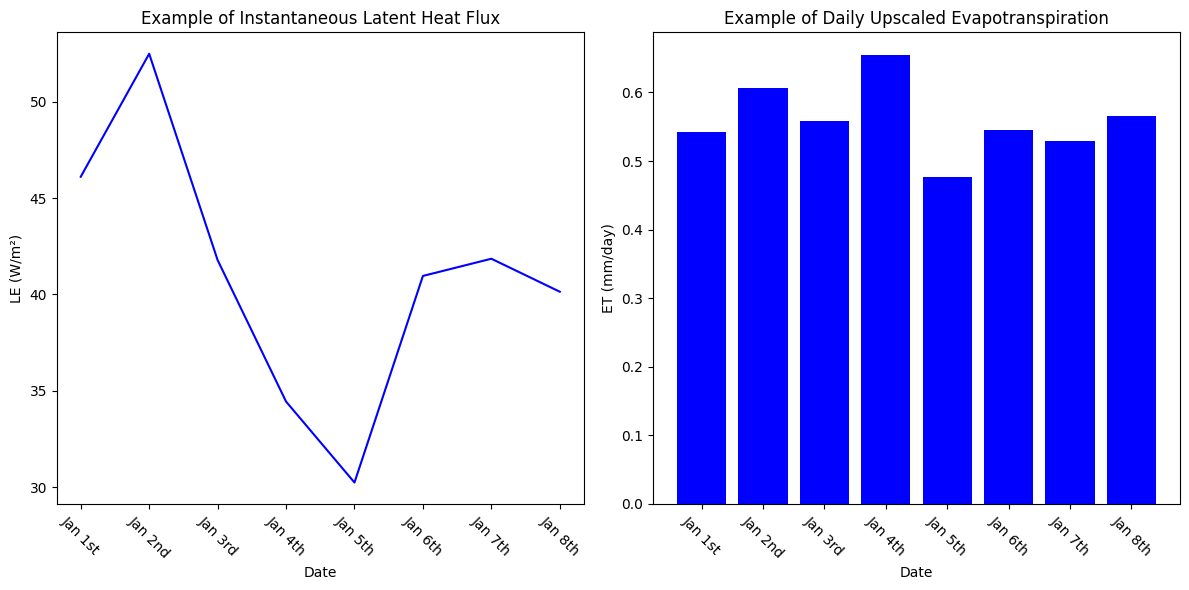

In [81]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# Custom formatter for ordinal date strings (e.g., "Apr 11th")
def format_ordinal_date(x, pos):
    dt = mdates.num2date(x)
    day = dt.day
    suffix = 'th' if 11 <= day <= 13 else {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')
    return f"{dt.strftime('%b')} {day}{suffix}"

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# LE on the left
axes[0].plot(month_df.time_UTC, month_df.LE_Wm2, label="LE_Wm2", color="blue")
axes[0].set_title("Example of Instantaneous Latent Heat Flux")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("LE (W/m²)")

# ET on the right
axes[1].bar(month_df.time_UTC, month_df.ET_daylight_kg, label="ET_daylight_kg", color="blue")
axes[1].set_title("Example of Daily Upscaled Evapotranspiration")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("ET (mm/day)")

# Apply custom x-axis date formatter and rotation
date_fmt = ticker.FuncFormatter(format_ordinal_date)
for ax in axes:
    ax.xaxis.set_major_formatter(date_fmt)
    ax.tick_params(axis='x', rotation=-45)

plt.tight_layout()
plt.show()

In [46]:
tower_df.time_UTC

336    2019-02-17T23:19:38Z
337    2019-05-26T00:20:14Z
338    2019-06-01T21:47:09Z
339    2019-10-05T19:51:04Z
340    2019-10-09T18:13:47Z
               ...         
399    2022-05-25T22:41:05Z
400    2022-05-29T21:05:31Z
401    2022-06-01T20:17:13Z
402    2022-06-02T19:29:30Z
403    2022-06-05T18:41:27Z
Name: time_UTC, Length: 68, dtype: str

In [36]:
processed.LE_Wm2

0       351.448461
1       326.039533
2       335.227018
3       332.815927
4       290.934683
           ...    
1060     35.172963
1061     37.569782
1062     27.267394
1063     58.151032
1064     99.428425
Name: LE_Wm2, Length: 1065, dtype: float64

In [35]:
processed.ET_daylight_kg

0       4.144935
1       4.279363
2       4.353823
3       4.433066
4       4.244395
          ...   
1060    0.423263
1061    0.815033
1062    0.585193
1063    1.076440
1064    1.231444
Name: ET_daylight_kg, Length: 1065, dtype: float64

[2026-08-25 18:03:54 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 18:03:54 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


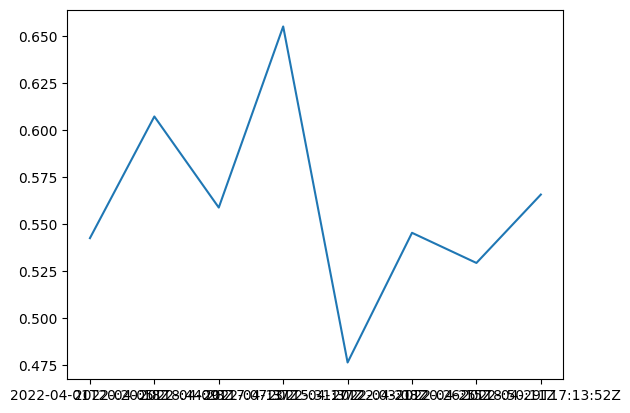

In [83]:
plt.plot(month_df.time_UTC, month_df.ET_daylight_kg)

[2026-08-25 18:06:07 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 18:06:07 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 18:06:07 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


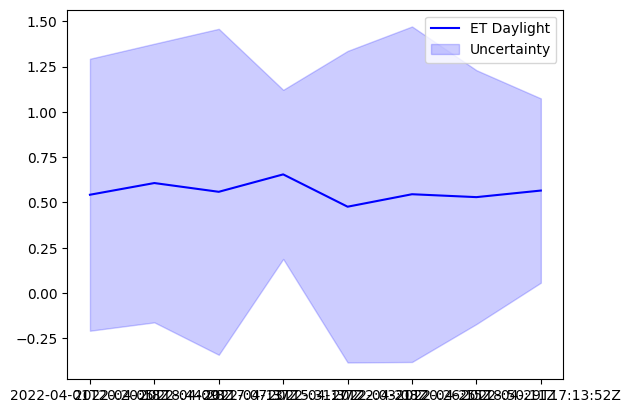

In [86]:
import matplotlib.pyplot as plt

# Plot the main trend line
plt.plot(month_df.time_UTC, month_df.ET_daylight_kg, color='blue', label='ET Daylight')

# Add the shaded uncertainty ribbon
plt.fill_between(
    month_df.time_UTC,
    month_df.ET_daylight_kg - month_df.ET_uncertainty,  # Lower bound
    month_df.ET_daylight_kg + month_df.ET_uncertainty,  # Upper bound
    color='blue',
    alpha=0.2,  # Transparency level
    label='Uncertainty'
)

plt.legend()

[2026-08-25 18:06:50 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 18:06:50 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 18:06:50 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


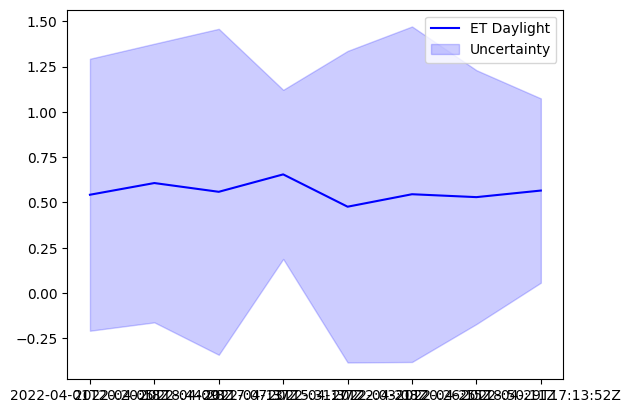

In [87]:
import matplotlib.pyplot as plt

# Plot the main trend line
plt.plot(month_df.time_UTC, month_df.ET_daylight_kg, color='blue', label='ET Daylight')

# Add the shaded uncertainty ribbon
plt.fill_between(
    month_df.time_UTC,
    month_df.ET_daylight_kg - month_df.ET_uncertainty,  # Lower bound
    month_df.ET_daylight_kg + month_df.ET_uncertainty,  # Upper bound
    color='blue',
    alpha=0.2,  # Transparency level
    label='Uncertainty'
)

plt.legend()

[2026-08-25 18:08:17 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 18:08:17 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 18:08:17 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


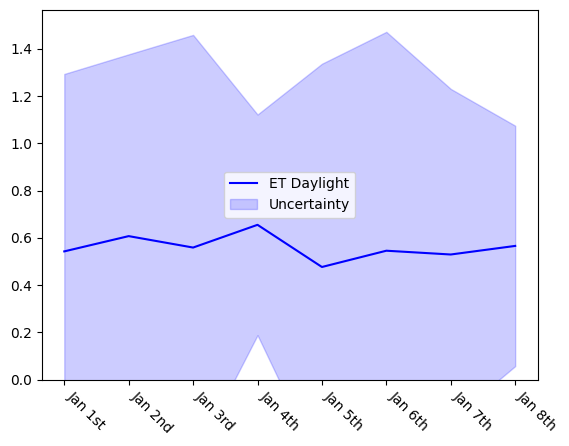

In [89]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter  # Import from ticker module

# Helper function to generate ordinal day suffix
def ordinal_date_formatter(x, pos=None):
    dt = mdates.num2date(x)
    day = dt.day
    if 11 <= day <= 13:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')
    return f"{dt.strftime('%b')} {day}{suffix}"

# Plot main trend line and uncertainty ribbon
plt.plot(month_df.time_UTC, month_df.ET_daylight_kg, color='blue', label='ET Daylight')
plt.fill_between(
    month_df.time_UTC,
    month_df.ET_daylight_kg - month_df.ET_uncertainty,
    month_df.ET_daylight_kg + month_df.ET_uncertainty,
    color='blue',
    alpha=0.2,
    label='Uncertainty'
)

# Apply custom x-axis date format
plt.gca().xaxis.set_major_formatter(FuncFormatter(ordinal_date_formatter))

# Rotate labels -45 degrees and align them to the tick mark
plt.xticks(rotation=-45, ha='left')

plt.ylim(bottom=0)
plt.legend()

[2026-08-25 18:10:58 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 18:10:58 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 18:10:58 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 18:10:58 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-25 18:10:58 INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these stri

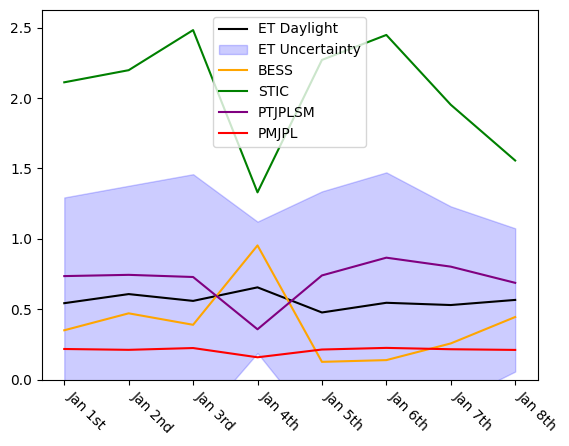

In [93]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Helper function to generate ordinal day suffix
def ordinal_date_formatter(x, pos=None):
    dt = mdates.num2date(x)
    day = dt.day
    if 11 <= day <= 13:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')
    return f"{dt.strftime('%b')} {day}{suffix}"

# Plot main trend line and uncertainty ribbon
plt.plot(month_df.time_UTC, month_df.ET_daylight_kg, color='black', label='ET Daylight')
plt.fill_between(
    month_df.time_UTC,
    month_df.ET_daylight_kg - month_df.ET_uncertainty,
    month_df.ET_daylight_kg + month_df.ET_uncertainty,
    color='blue',
    alpha=0.2,
    label='ET Uncertainty'
)

# Plot additional model lines
plt.plot(month_df.time_UTC, month_df.ET_daylight_BESS_kg, color='orange', label='BESS')
plt.plot(month_df.time_UTC, month_df.ET_daylight_STIC_kg, color='green', label='STIC')
plt.plot(month_df.time_UTC, month_df.ET_daylight_PTJPLSM_kg, color='purple', label='PTJPLSM')
plt.plot(month_df.time_UTC, month_df.ET_daylight_PMJPL_kg, color='red', label='PMJPL')

# Apply custom x-axis date format
plt.gca().xaxis.set_major_formatter(FuncFormatter(ordinal_date_formatter))

# Rotate labels -45 degrees and align them to the tick mark
plt.xticks(rotation=-45, ha='left')

plt.ylim(bottom=0)
plt.legend()